In [ ]:
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from dataset import load_audio, to_log_mel, MashupDataset, split_songs
from config import CFG, GENRE_MAP

GENRE   = "blues"   # any genre
SEED    = 42
random.seed(SEED); np.random.seed(SEED)

splits   = split_songs(CFG.TRAIN_STEMS, seed=SEED)
song_dir = splits["train"][GENRE][0]
wav_path = song_dir / "other.wav"

raw      = load_audio(wav_path)
stretched = librosa.effects.time_stretch(raw.copy(), rate=1.1)

noise_files = sorted(CFG.NOISE_DIR.glob("*.wav"))
noise  = load_audio(random.choice(noise_files))
n_clip = noise[:len(raw)] if len(noise) >= len(raw) else np.pad(noise, (0, len(raw)-len(noise)))
sig_rms, n_rms = np.sqrt(np.mean(raw**2)), max(np.sqrt(np.mean(n_clip**2)), 1e-8)
noisy  = raw + n_clip * (sig_rms / (10**(20/20)) / n_rms)   # SNR = 20 dB
noisy /= max(np.abs(noisy).max(), 1e-6)

  train: 800 songs
  val  : 100 songs
  test : 100 songs


/home/shrek/Desktop/Projects/dlgenai/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


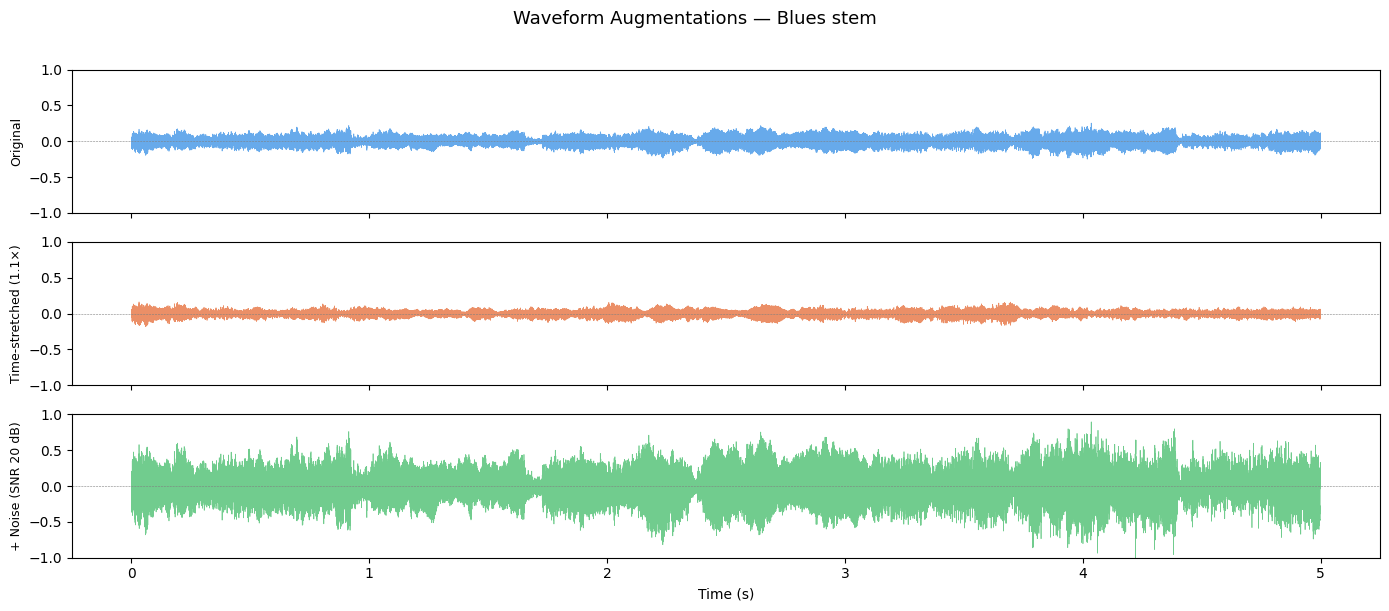

In [ ]:
T   = 5   # secs
N   = T * CFG.SR
t   = np.linspace(0, T, N)
clips = [(raw[:N],       "Original",            "#4C9BE8"),
         (stretched[:N], "Time-stretched (1.1×)", "#E87C4C"),
         (noisy[:N],     "+ Noise (SNR 20 dB)",  "#58C47A")]

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"Waveform Augmentations — {GENRE.capitalize()} stem", fontsize=13, y=1.01)
for ax, (clip, title, color) in zip(axes, clips):
    ax.plot(t, clip, lw=0.5, color=color, alpha=0.85)
    ax.set_ylabel(title, fontsize=9)
    ax.set_ylim(-1, 1)
    ax.axhline(0, lw=0.4, color="gray", linestyle="--")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

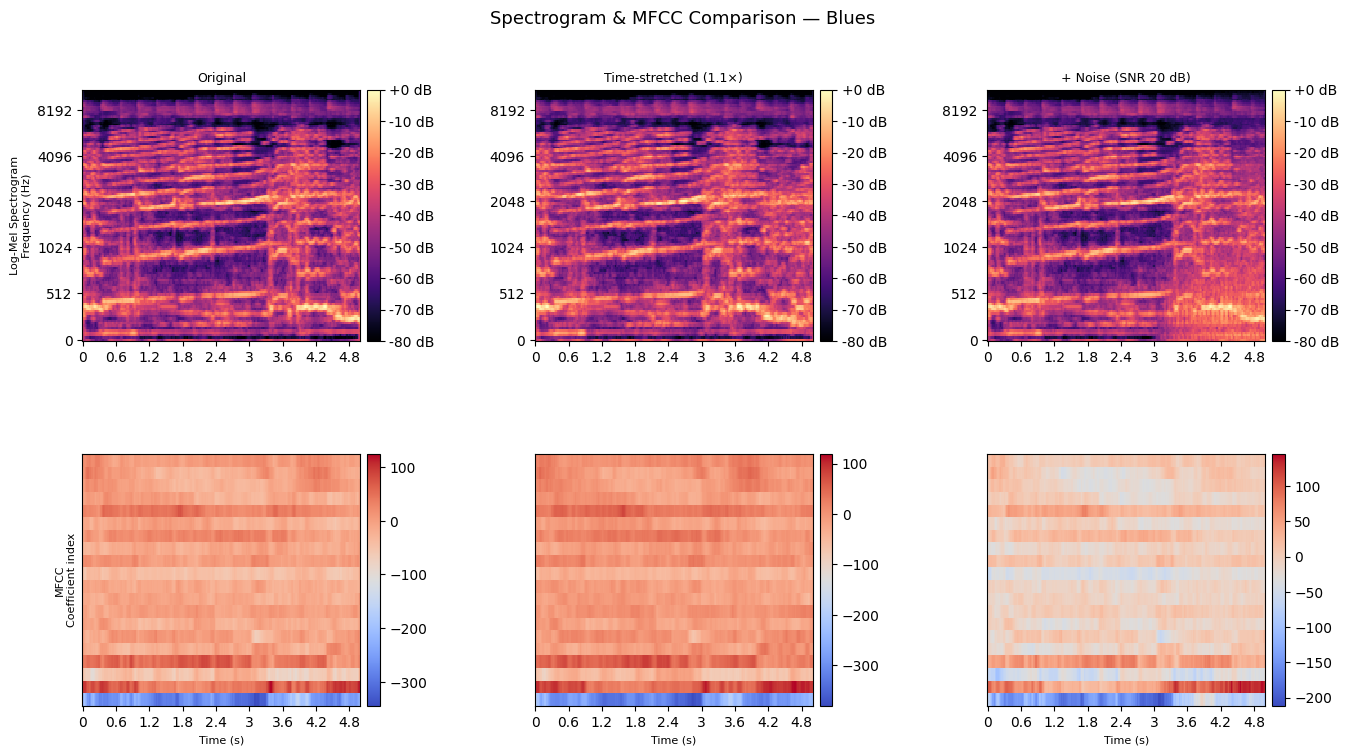

In [3]:
mels  = [(to_log_mel(c), lbl) for c, lbl, _ in clips]
mfccs = [(librosa.feature.mfcc(y=c, sr=CFG.SR, n_mfcc=20), lbl) for c, lbl, _ in clips]
colors = [c for _, _, c in clips]

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

for col, ((mel, lbl), (mfcc, _), color) in enumerate(zip(mels, mfccs, colors)):
    # spectrogram row
    ax_mel = fig.add_subplot(gs[0, col])
    img = librosa.display.specshow(mel, sr=CFG.SR, hop_length=CFG.HOP_LENGTH,
                                   x_axis="time", y_axis="mel", ax=ax_mel, cmap="magma")
    ax_mel.set_title(lbl, fontsize=9)
    ax_mel.set_xlabel("")
    if col == 0: ax_mel.set_ylabel("Log-Mel Spectrogram\nFrequency (Hz)", fontsize=8)
    else:        ax_mel.set_ylabel("")
    plt.colorbar(img, ax=ax_mel, format="%+2.0f dB", pad=0.02)

    # MFCC row
    ax_mf = fig.add_subplot(gs[1, col])
    img2  = librosa.display.specshow(mfcc, sr=CFG.SR, hop_length=CFG.HOP_LENGTH,
                                     x_axis="time", ax=ax_mf, cmap="coolwarm")
    ax_mf.set_xlabel("Time (s)", fontsize=8)
    if col == 0: ax_mf.set_ylabel("MFCC\nCoefficient index", fontsize=8)
    else:        ax_mf.set_ylabel("")
    plt.colorbar(img2, ax=ax_mf, pad=0.02)

fig.suptitle(f"Spectrogram & MFCC Comparison — {GENRE.capitalize()}", fontsize=13)
plt.show()